<img src="./logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº3
#### Serena Saggion


# Introducción
En este trabajo práctico se analiza el comportamiento espectral de señales senoidales mediante la Transformada Rápida de Fourier (FFT). En particular, se estudia el efecto del desparramo espectral producido cuando la frecuencia de la señal no coincide exactamente con un bin de la DFT. Además, se verifica la potencia de las señales mediante la identidad de Parseval y se evalúa el efecto de la técnica de zero padding, analizando cómo modifica la representación del espectro y la visualización de las componentes frecuenciales sin aumentar la resolución espectral real.

# Teoría

### Densidad Espectral de Potencia (PSD)

La Densidad Espectral de Potencia (PSD) describe cómo se distribuye la potencia de una señal en función de la frecuencia. En la práctica, la PSD puede estimarse mediante el **periodograma**, calculado a partir del módulo al cuadrado de la Transformada Discreta de Fourier (DFT) de la señal.

\begin{equation}PSD[k]=\frac{|X[k]|^2}{N,fs}\end{equation}

donde (X[k]) es la DFT de la señal, (N) el número de muestras y (fs) la frecuencia de muestreo.

### Bins de la DFT

La DFT evalúa el espectro únicamente en un conjunto discreto de frecuencias denominadas **bins**. La separación entre bins está dada por
\begin{equation}\Delta f=\frac{f_s}{N}\end{equation}

Si la frecuencia de una señal coincide exactamente con uno de estos bins, la energía se concentra en dicho punto. En cambio, si la frecuencia queda entre dos bins, la energía se distribuye entre varios de ellos.

### Desparramo espectral (Spectral Leakage)

El desparramo espectral ocurre cuando una componente de frecuencia no coincide exactamente con un bin de la DFT o cuando se analiza una señal de duración finita. Como consecuencia, la energía deja de concentrarse en un único bin y se reparte entre frecuencias vecinas, generando un lóbulo principal y lóbulos laterales en el espectro.

### Zero Padding

La técnica de **zero padding** consiste en agregar ceros al final de la señal antes de calcular la FFT. Esto incrementa el número de puntos de la transformada y disminuye la separación entre bins, permitiendo una representación más densa del espectro. Sin embargo, no aumenta la resolución espectral real ni agrega información nueva a la señal; únicamente interpola el espectro y facilita la visualización de los picos espectrales.

### Identidad de Parseval

La identidad de Parseval establece que la energía o potencia de una señal es la misma tanto en el dominio temporal como en el dominio frecuencial. Para la FFT utilizada en este trabajo se verifica mediante

\begin{equation}\frac{1}{N}
\sum_{k=0}^{N-1}|X[k]|^2\end{equation}

Esta propiedad permite comprobar que la potencia calculada a partir de la señal coincide con la obtenida a partir de su espectro.


# Procedimiento
1) Sea **k0 = N/4; N/4+0.25; N/4+0.5**
 
A cada senoidal se le agrega una pequeña desintonía respecto a  Δf, graficar las tres densidades espectrales de potencia (PDS's) y discutir cuál es el efecto de dicha desintonía en el espectro visualizado.

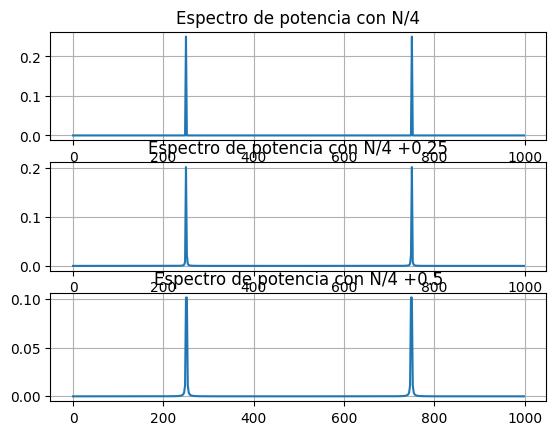

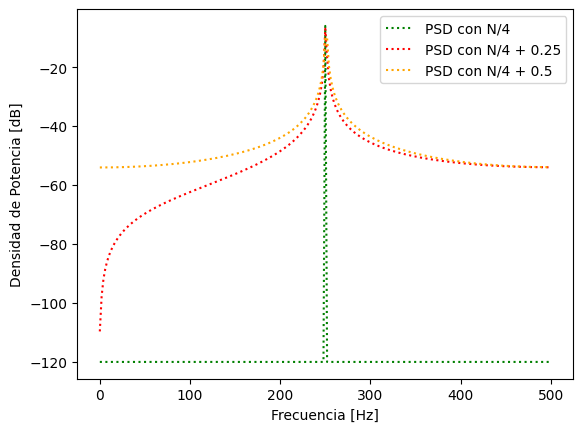

In [17]:
import matplotlib.pyplot as plt
import numpy as np


def mi_sen(vmax, dc, ff, ph, nn, fs):    
    #vmax, dc,ff,ph tienen valor por defecto
    Ts=1/fs 
    tt=np.arange(nn)*Ts
    xx=dc+vmax*np.sin(2*np.pi*ff*tt + ph)
    return tt,xx


fs=1000
Ts=1/fs 
N=fs/2
tt=np.arange(N)*Ts

df=fs/N
ff=np.arange(N)*df


tt,s1= mi_sen(vmax=np.sqrt(2), dc=0,ff=fs/4, ph=0, nn=N, fs=fs)
tt,s2= mi_sen(vmax=np.sqrt(2), dc=0,ff=(fs/N)*(N/4 + 0.25), ph=0, nn=N, fs=fs)
tt,s3= mi_sen(vmax=np.sqrt(2), dc=0,ff=(fs/N)*(N/4 + 0.5), ph=0, nn=N, fs=fs)


#Periodograma -> fft->modulo al cuadrado
S1=np.fft.fft(s1)
PSD1=((np.abs(S1))**2)*(1/(N*fs))
#S1phase=np.angle(S1)

S2=np.fft.fft(s2)
PSD2=((np.abs(S2))**2)*(1/(N*fs))
#S2phase=np.angle(S2)

S3=np.fft.fft(s3)
PSD3=((np.abs(S3))**2)*(1/(N*fs))
#S3phase=np.angle(S3)

eps = 1e-12

plt.figure()
plt.subplot(3,1,1)
plt.plot(ff,PSD1 + eps)
plt.title("Espectro de potencia con N/4")
plt.grid()

plt.subplot(3,1,2)
plt.plot(ff,PSD2 + eps)
plt.title("Espectro de potencia con N/4 +0.25")
plt.grid()

plt.subplot(3,1,3)
plt.plot(ff,PSD3 + eps)
plt.title("Espectro de potencia con N/4 +0.5")
plt.grid()
plt.show()



Pot1_dB=(10*np.log10(PSD1 + eps))
Pot2_dB=(10*np.log10(PSD2 + eps))
Pot3_dB=(10*np.log10(PSD3 + eps))

bBool=ff<=fs/2
plt.figure()
plt.plot(ff[bBool],Pot1_dB[bBool], color="green", linestyle=":", label="PSD con N/4")
plt.plot(ff[bBool],Pot2_dB[bBool], color="red", linestyle=":", label="PSD con N/4 + 0.25")
plt.plot(ff[bBool],Pot3_dB[bBool], color="orange", linestyle=":", label="PSD con N/4 + 0.5")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
plt.legend()
plt.show()

2) Verificar la potencia unitaria de cada PSD, puede usar la identidad de Parseval. En base a la teoría estudiada. Discuta la razón por la cual una señal senoidal tiene un espectro tan diferente respecto a otra de muy pocos Hertz de diferencia.

In [18]:
#%%

P1_f = np.sum(np.abs(S1)**2)/(N**2)
P2_f = np.sum(np.abs(S2)**2)/(N**2)
P3_f = np.sum(np.abs(S3)**2)/(N**2)

print(f"Parseval 1: {P1_f:.2f}")  #redondeo el valor a dos dígitos
print(f"Parseval 2: {P2_f:.2f}")
print(f"Parseval 3: {P3_f:.2f}")

#%%

Parseval 1: 1.00
Parseval 2: 1.00
Parseval 3: 1.00


3) Repetir el experimento mediante la técnica de zero padding. Probar agregando un vector de 9*N ceros al final.

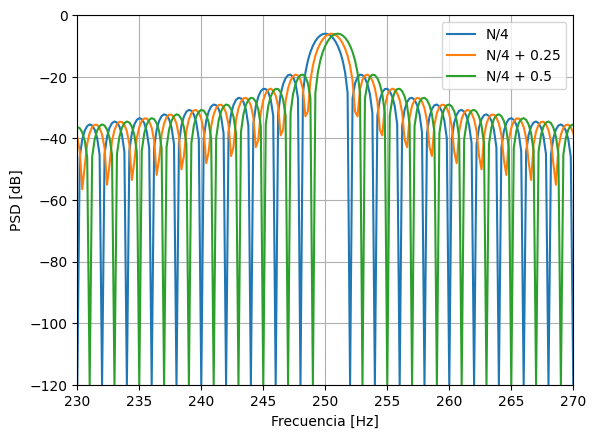

In [19]:
Nz = 10*N

s1_zp = np.concatenate([s1, np.zeros(int(9*N))])
s2_zp = np.concatenate([s2, np.zeros(int(9*N))])
s3_zp = np.concatenate([s3, np.zeros(int(9*N))])

ff_zp = np.arange(Nz) * fs/Nz

S1_zp = np.fft.fft(s1_zp)
S2_zp = np.fft.fft(s2_zp)
S3_zp = np.fft.fft(s3_zp)

PSD1_zp = (np.abs(S1_zp)**2)/(N*fs)
PSD2_zp = (np.abs(S2_zp)**2)/(N*fs)
PSD3_zp = (np.abs(S3_zp)**2)/(N*fs)

eps = 1e-12  #por si diverge

PSD1_zp_dB = 10*np.log10(PSD1_zp + eps)
PSD2_zp_dB = 10*np.log10(PSD2_zp + eps)
PSD3_zp_dB = 10*np.log10(PSD3_zp + eps)

bBool = ff_zp <= fs/2

plt.figure()
plt.plot(ff_zp[bBool], PSD1_zp_dB[bBool], label="N/4")
plt.plot(ff_zp[bBool], PSD2_zp_dB[bBool], label="N/4 + 0.25")
plt.plot(ff_zp[bBool], PSD3_zp_dB[bBool], label="N/4 + 0.5")
plt.xlim(230, 270)
plt.ylim(-120, 0)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB]")
plt.grid()
plt.legend()
plt.show()

# Analisis de Resultados
## Ejercicio A
Al introducir una desintonía respecto de los bins de la DFT, se observa el fenómeno de desparramo espectral. La energía deja de concentrarse en un único bin y se distribuye entre varios bins vecinos, aumentando el ancho aparente del lóbulo principal. En el caso de k0 =N/4+0.5, la frecuencia se encuentra exactamente a mitad de camino entre dos bins, por lo que la energía se reparte entre ambos y la amplitud máxima del pico se reduce aproximadamente a la mitad respecto del caso en que la frecuencia coincide exactamente con un bin.

## Ejercicio B
Mediante la identidad de Parseval se verificó que las tres señales poseen potencia unitaria. Los valores obtenidos fueron aproximadamente iguales a 1, confirmando que la potencia calculada en el dominio temporal coincide con la obtenida en el dominio frecuencial.

## Ejercicio C
Al aplicar la técnica de zero padding, se obtuvo una representación más específica del espectro de potencia debido a la disminución de la separación entre bins de la FFT. Esto permitió visualizar con mayor claridad la posición de los picos espectrales y comprobar que las señales desintonizadas no coinciden exactamente con un bin de la DFT. Además, en el caso de la señal con frecuencia N/4, se observa que aparecen el lóbulo principal y los lóbulos laterales, sin zero padding no eran visibles porque la FFT original muestreaba el espectro en pocos puntos y, al coincidir la frecuencia exactamente con un bin, los demás bins caían sobre los ceros de la función sinc.

# Conclusión

En este trabajo se analizó el comportamiento espectral de señales senoidales mediante la Transformada Rápida de Fourier, estudiando el efecto de la desintonía respecto de los bins de la FFT y la influencia del **spectral leakage**. Se observó que, cuando la frecuencia de la señal coincide exactamente con un bin de la DFT, la energía se concentra en dicho bin. En cambio, al introducir pequeñas desintonías, la energía se distribuye entre varios bins, dando lugar al desparramo espectral y a una disminución de la amplitud máxima del pico, aun cuando la potencia total de la señal permanece constante.

Mediante la identidad de Parseval se verificó que las tres señales poseen potencia unitaria, comprobando la equivalencia entre la energía calculada en los dominios temporal y frecuencial.

Finalmente, se aplicó la técnica de **zero padding**, observándose que aumenta la cantidad de puntos de la FFT y reduce la separación entre bins, permitiendo una representación más detallada del espectro y una mejor estimación de la posición de las componentes espectrales. Se comprobó que esta técnica no mejora la resolución espectral real ni elimina el desparramo espectral, sino que únicamente interpola el espectro obtenido a partir de la señal original. En conjunto, los resultados permitieron comprender cómo la posición de la frecuencia de una señal respecto de los bins de la DFT influye significativamente en el espectro obtenido. Además, se evidenció que el análisis de señales de longitud finita introduce limitaciones, como el desparramo espectral y la resolución finita en frecuencia, que deben considerarse al interpretar los resultados de la FFT.
